In [32]:
import glob
import os

#set current working directory
os.chdir('/home/jovyan')

#list files in shared folder
files = glob.glob("/shared_space/Galveston_Bay/*")
files



/home/jovyan


['/shared_space/Galveston_Bay/all_basin_data.txt',
 '/shared_space/Galveston_Bay/TST_Monitoring_Data_May2025_for_HGAC_Website.xlsx',
 '/shared_space/Galveston_Bay/SWQM_Stations.csv']

In [33]:
# I used this to move the file from my local to the shared folder

# import shutil
# source = "./work/GalvestonBay/SWQM_Stations.csv"
# destination = "/shared_space/Galveston_Bay/SWQM_Stations.csv"
# shutil.move(source, destination)

# Ground Truth Data

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature


###  The Texas Clean Rivers Program  

Guide to Parameter Codes:
https://www.tceq.texas.gov/downloads/water-quality/data-management/reference-guide/dmrg-ch6.pdf

Desciption of Data: 
https://www.h-gac.com/getmedia/1c8428a2-7245-47a2-aac4-84f1ae6dc6d0/Data-Field-Descriptions-and-Use

In [50]:
file_path = "/shared_space/Galveston_Bay/all_basin_data.txt"
crp = pd.read_csv(file_path, sep="|")
#print(df.dtypes)
#crp.head()

In [44]:
len(crp['STATION_ID'].unique())

10245

In [51]:
DO_crp=crp[crp['parameter_code']==300]
Temp_crp=crp[crp['parameter_code']==10]

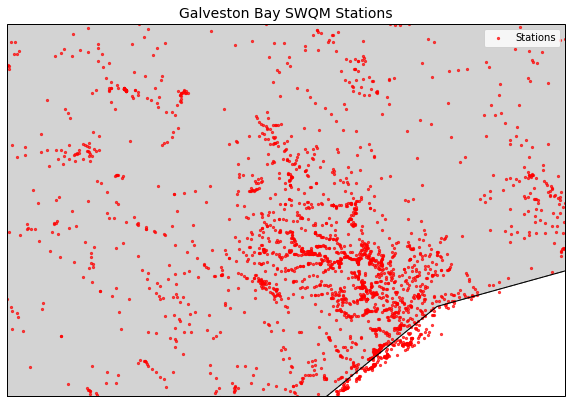

In [21]:

file_path = "/shared_space/Galveston_Bay/SWQM_Stations.csv"
crp_stations = pd.read_csv(file_path)

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linestyle="--", alpha=0.5)
ax.set_extent([-97, -94, 29, 31], crs=ccrs.PlateCarree())

ax.scatter(crp_stations["LONG_DD"], crp_stations["LAT_DD"], c="red", s=5, alpha=0.7, transform=ccrs.PlateCarree(),label="Stations")
ax.set_title("Galveston Bay SWQM Stations", fontsize=14)
plt.legend()
plt.show()


###  The Texas Clean Rivers Program  

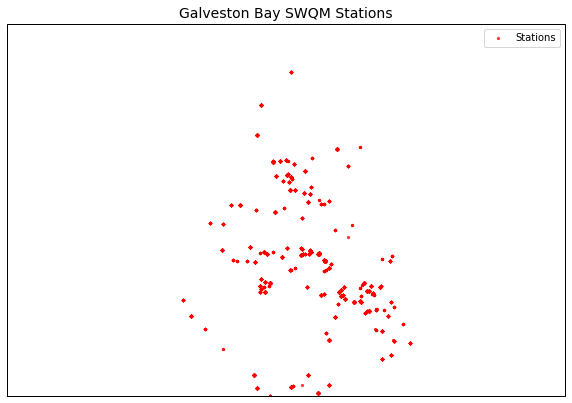

In [39]:
file_path = "/shared_space/Galveston_Bay/TST_Monitoring_Data_May2025_for_HGAC_Website.xlsx"
cr = pd.read_excel(file_path)

import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

stamen = cimgt.Stamen('terrain')
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

#ax.add_image(stamen, 10)
ax.set_extent([-97, -94, 29, 31], crs=ccrs.PlateCarree())

ax.scatter(cr["LONGITUDE"], cr["LATITUDE"], c="red", s=5, alpha=0.7, transform=ccrs.PlateCarree(),label="Stations")
ax.set_title("Galveston Bay SWQM Stations", fontsize=14)
plt.legend()
plt.show()
